Project Title: Analyzing Solar Imagery and Identifying Active Regions using Aditya-L1 data. 
The image downloaded for the analysis is dated 09-05-2026 at 07:09:21 AM. The image is a level 1 image. 
The image is an off centered image of the sun which means that there are strong distortions in the western and southern hemispheres as mentioned in the PRADAN portal. 
The image is filtered by NB03 filter (central wavelength = 279.6 nm, bandpass = 0.4nm)

In [11]:
# Imports:

import sys
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from astropy.io import fits
import sunpy.map 

from suitcolormap import suit_cmap, suit_norm
from scipy.ndimage import uniform_filter
from skimage.filters import threshold_otsu

In [12]:
# Loading the file: 

# we will now load the FITS file to the notebook and view the raw image: 
smap = sunpy.map.Map(r'C:\Users\acer\Desktop\ISA\Project work\Data\Raw\SUT_T26_0649_002132_Lev1.0_2026-05-09T07.09.21.400_08B2NB03.fits')
'''

'''

'\n\n'

<Figure size 800x800 with 0 Axes>

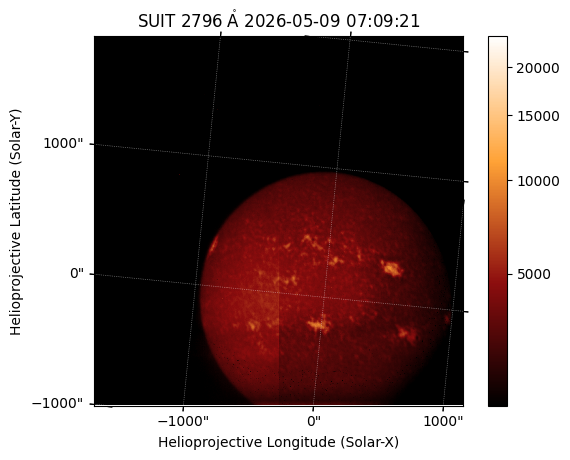

In [13]:
# Displaying Raw Image: 
cmap = suit_cmap('NB03')  # We have taken data from NB03 filter, hence we need to implement its color map.
plt.figure(figsize=(8,8))
smap.peek(cmap=cmap, vmin = 100, draw_grid= False)  
# We have taken a custom vmin value to ensure that we can differentiate sun from background.

NOTE: PRADAN portal warns- SUIT data taken in the off-centered position is highly distorted in the southern and western hemispheres. This needs to be taken into account for our analysis.

We have successfully imported the FITS file and displayed raw image in our notebook. We will now perform preprocessing of this image in order to convert this image from level 1 to level 2.  

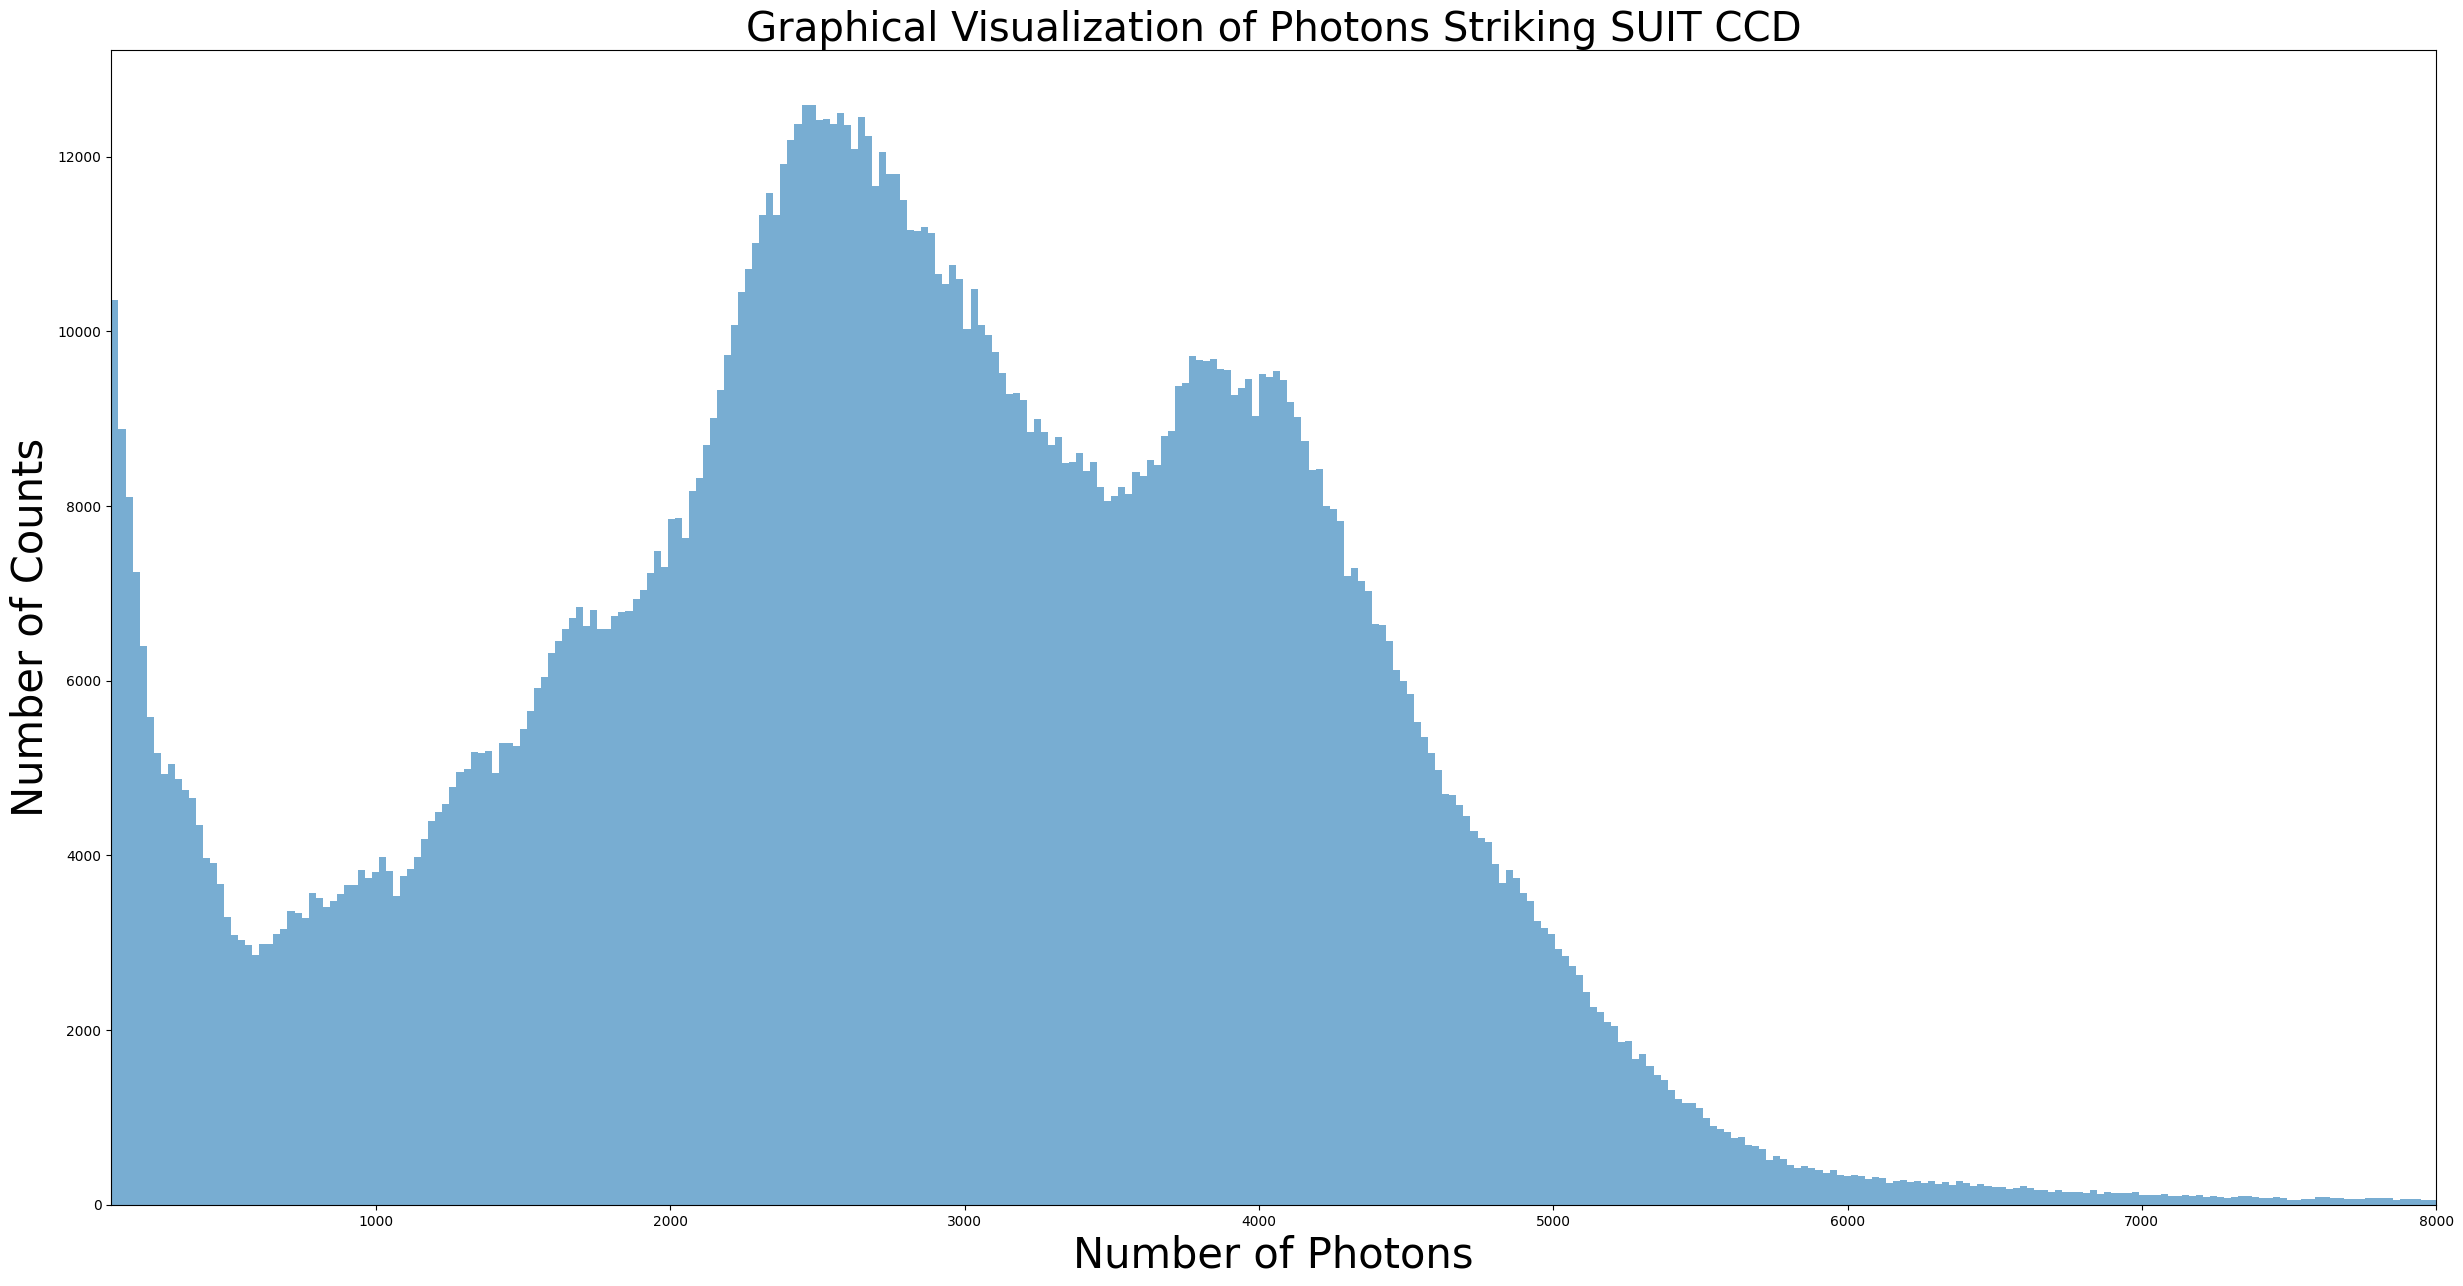

In [14]:
# Understanding histogram is necessary before performing preprocessing: 

arr_2d = smap.data     # 2048 x 2048 array
# arr_2d is the array in which each element  corresponds to photon count on each pixel of SUIT. 
arr_1d = arr_2d.flatten()
'''The array consists of many negative values which have no physical significance and so we have to remove them in
order to perform accurate analysis.'''
arr_1d[arr_1d<0]=0
arr_solar = arr_1d[arr_1d>100]
plt.figure(figsize=(30,15))
plt.hist(arr_solar, bins=1000, alpha=0.6)
plt.xlim(100,8000)
plt.xlabel('Number of Photons', fontsize= 30)
plt.ylabel('Number of Counts', fontsize=30)
plt.title('Graphical Visualization of Photons Striking SUIT CCD', fontsize = 29)
plt.show()

The following observations can be made form the histogram: 

1. We can see that two distinguishable peaks are formed in our graph. These peaks are of physical significance:
   a. The first peak corresponds to the quiet part of the sun that is the regions of sun except the active regions.
   b. The second peak corresponds to the solar limb or chromospheric limb. As can be seen from the graph it is brighter than the quiet sun but less brighter than active regions of the sun. 
2. The region of the graph corresponding to the active regions is the region after the second peak. Their count may be less but, they are brighter than rest of the sun. There is a reason why they are less in count, it i because they cover very less area of the sun's surface which can also be seen from our graph.     

In [15]:
# Flat-Field Correction: 
''' Flat-field correction is done to make for the errors which arise due to erroneous sensitivity of the pixels
which leads to artificial counts. It smoothens the abrupt rises and falls in the plot and only keeps the smooth
variations. 
This is done by applying uniform filter. Each output pixel is the average of all pixels in the neighborhood. 
'''

arr_2d[arr_2d<0] = 0
flat_field = uniform_filter(arr_2d, size=100)
'''We have selected size=100 as it not compromising the spatial details of detector and also gives us a valid enough flat field to work with.'''
# Applying correction: 

flat_field[flat_field<1]=1 # This is being done to prevent the division of arr_2d from 0 as flat_field contains many 0 values.
arr_ffc = arr_2d/flat_field * np.median(flat_field[flat_field>1])


I have applied flat field correction to our image and now we will plot the image to see what has flat field correction has done to our image.

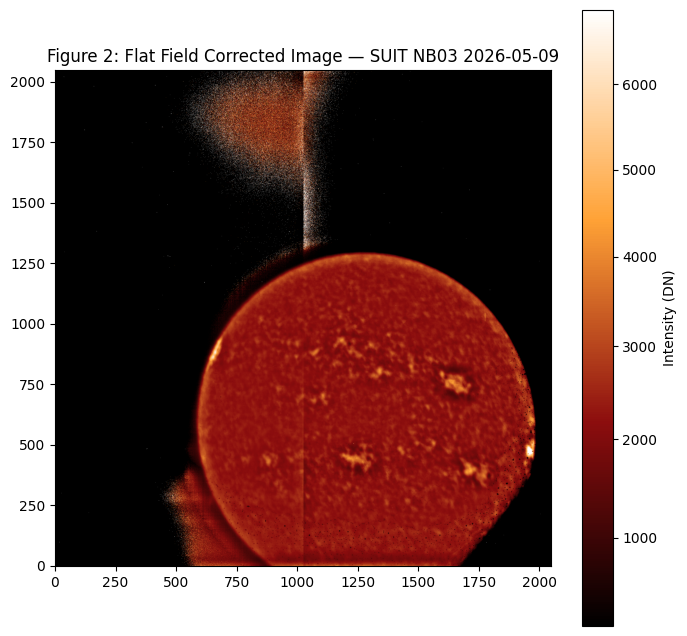

In [16]:
# Displaying Flat Field Corrected image: 
'''We will have to convert the ffc array to an image, we will use 'imshow' function for it.'''
cmap = suit_cmap('NB03')
norm = suit_norm(arr_ffc, 'NB03')
#plt.imshow(arr_ffc , cmap = cmap, vmin=np.percentile(arr_ffc,1), vmax=np.percentile(arr_ffc,99))
plt.figure(figsize=(8,8))
plt.imshow(arr_ffc , cmap = cmap, norm = norm, origin = 'lower')
plt.title('Figure 2: Flat Field Corrected Image — SUIT NB03 2026-05-09', fontsize= 12)
plt.colorbar(label='Intensity (DN)')
plt.show()

The following observations can be made from the above image:

1. There is a bright patch in the upper-left region and the vertical stripe near x=1000. These are expected calibration artifacts. The PRADAN portal notes that off-centered images may show significant distortion in western and southern hemispheres. 

2. The active regions in the sun are clearly visible as bright patches, in comparison to the quiet sun, on the solar disk.

3. Before we proceed to Otsu thresholding, we would have to take care of the artifacts that are there in the image. Without their removal Otsu thresholding will be pulled in wrong place. This can be done by masking, that is removing 

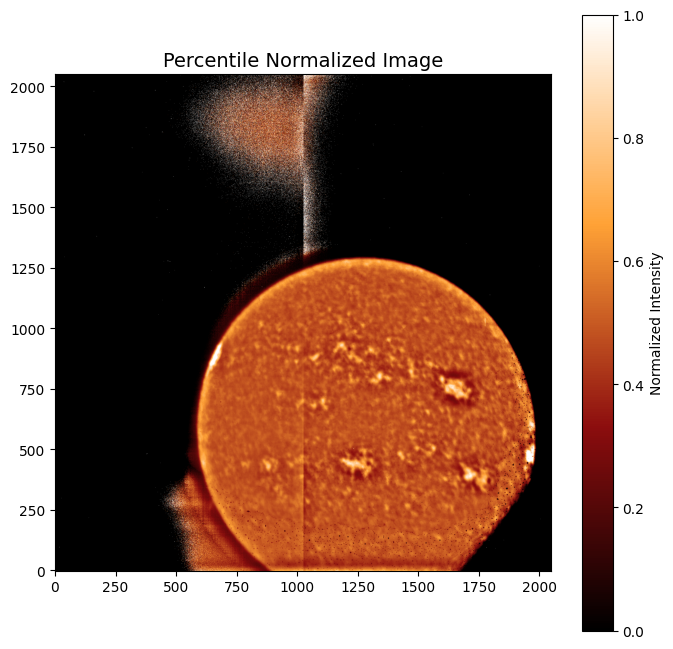

In [17]:
# Applying Percentile Normalization:
P1 = np.percentile(arr_ffc, 1)     # 0
P99 = np.percentile(arr_ffc, 99)   #4658.8745
arr_normalized = (arr_ffc-P1)/(P99-P1)  # Normalized array.
arr_normalized = np.clip(arr_normalized,0,1)  # so that all values stay between 0 and 1
plt.figure(figsize=(8,8))
plt.imshow(arr_normalized, cmap = cmap, origin = 'lower')
plt.colorbar(label='Normalized Intensity')
plt.title('Percentile Normalized Image', fontsize=14)
plt.show()

Now we are going to resolve the problem of high distortion in the western and southern hemisphere. This can be done by removing the off-disk background of the image, this will neglect everything that is outside the solar disk. We will do it by masking.

In [18]:
# Masking the solar disk: 

x = np.arange(0, 2048)
y = np.arange(0, 2048)
X, Y = np.meshgrid(x, y)
radius = 775
x_center = 1320
y_center = 650
distance = np.sqrt((X-x_center)**2+(Y-y_center)**2)
mask = (distance<=radius)

arr_2d_masked = arr_normalized.copy()
arr_2d_masked[~mask] = 0

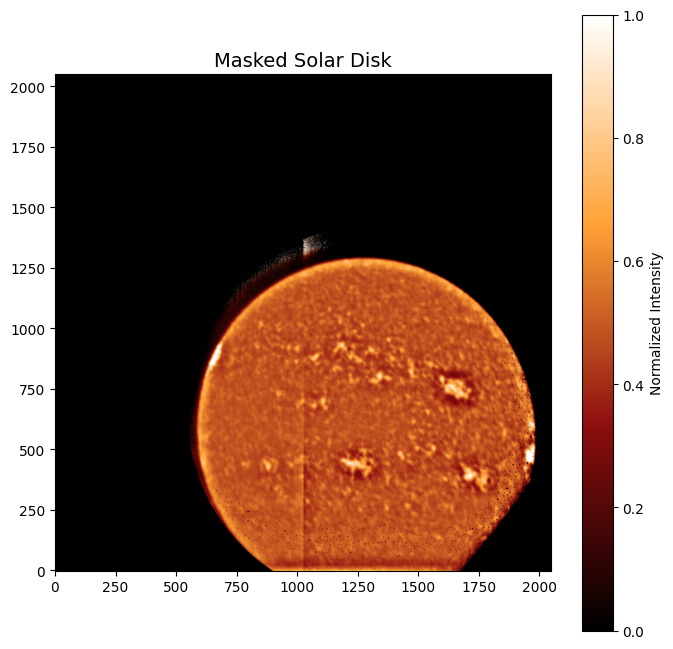

In [19]:
#Image of masked solar disk: 

plt.figure(figsize=(8,8))
norm = suit_norm(arr_2d_masked,'NB03')
plt.imshow(arr_2d_masked, cmap=cmap, origin='lower')
plt.colorbar(label='Normalized Intensity')
plt.title('Masked Solar Disk', fontsize=14)
plt.show()